# Building a ConvNP Model for NZRA data over Auckland

We have been provided NZRA data from the Auckland region, which provides a much higher-resolution view than ERA5. Additionally, more weather stations are available in the stations_v2 dataset, and data from the Himawari8 satellite is available. Using this new data, we want to build and validate a ConvNP for data assimilation at weather stations, with NZRA and H8 data as context sets.

In [2]:
# setup project root for imports (requirement for all notebooks in this repo)
import sys
from pathlib import Path

# Make project root importable
ROOT = Path().resolve().parents[1]
sys.path.append(str(ROOT))

In [3]:
# setup logging (useful for running with nohup)
from src.config.logging_config import setup_logging
import logging

setup_logging()  # configure logging
logger = logging.getLogger(__name__)
logger.info("Notebook execution started.")

# setup tensorboard logging
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

TB_TRAIN_LOSS = "Loss/Train"
TB_VAL_LOSS = "Loss/Validation"
TB_EXPERIMENT = "exp4_nzra"

tb_writer = SummaryWriter(log_dir=str(ROOT / ".tb_logs" / TB_EXPERIMENT / f"run_s1_{datetime.now().strftime('%d-%m %H:%M')}"))

2025-12-12 12:15:04 - INFO - __main__ - Notebook execution started.


In [4]:
%load_ext autoreload

In [5]:
%autoreload 2
from src.utils.variables.var_names import *
from src.utils.variables.coord_names import *
from src.data_processing.conversions.scalar_conversions import *
from src.config.env_loader import get_env_var
import src.learning.model_diagnostics as model_diagnostics
from src.learning.model_training import batch_data_by_num_stations, compute_val_loss

from src.data_processing.station_processor import ProcessStations
from src.data_processing.topography_processor import ProcessTopography
from src.data_processing.nzra_processor import ProcessNZRA
from src.data_processing.himawari8_processor import ProcessHimawari8
from src.data_processing.ifs_processor import ProcessIFS

from src.data_processing.auxiliary.sun_position import get_sun_culmination, get_sun_position
from src.data_processing.auxiliary.positional_encodings import build_cropped_auxiliary

In [6]:
# DeepSensor imports
# note this pulls from a fork of DeepSensor.
import deepsensor.torch
from deepsensor.train.train import train_epoch, set_gpu_default_device, concat_tasks
from deepsensor.data.loader import TaskLoader
from deepsensor.data.processor import DataProcessor
from deepsensor.model.convnp import ConvNP
from deepsensor.data.utils import construct_x1x2_ds

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from mpl_toolkits.basemap import Basemap
import torch
from torch import optim
import os
import lab as B
from tqdm import tqdm
import cartopy.crs as ccrs
import cartopy.feature as cf
import gc

In [7]:
# setup variables for experiment
years = [2017]

# set the target variable
target_var = TEMPERATURE

# model hyperparameters
batch_size = 32
n_epochs = 50
lr = 5e-5 * 2

# GPU settings
use_gpu = True
if use_gpu:
    cuda_device = int(get_env_var("CUDA_DEVICE"))
    set_gpu_default_device(backend="cuda", dev_id=cuda_device)

### Load the Datasets

In [8]:
logger.info("Starting data processing.")

2025-12-12 12:15:10 - INFO - __main__ - Starting data processing.


In [9]:
station_processor = ProcessStations(mode="csv")
topography_processor = ProcessTopography()
nzra_processor = ProcessNZRA()
h8_processor = ProcessHimawari8()
ifs_processor = ProcessIFS()

In [10]:
stations_df = station_processor.load_df(vars=[TEMPERATURE], csv_file="esnz-observations_temp_20170101-20171231.csv")
topography_ds = topography_processor.load_ds()
nzra_ds = nzra_processor.load_ds(years=years)
h8_ds = h8_processor.load_ds(years=years)
ifs_ds = ifs_processor.load_ds(years=years)

#### Clean up the NZRA dataset
- Convert temperature to celsius (if required)
- This will be the target set

In [11]:
logger.info("Processing NZRA")

2025-12-12 12:15:42 - INFO - __main__ - Processing NZRA


In [12]:
nzra_target = nzra_ds[target_var]

if target_var == TEMPERATURE:
    nzra_target = kelvin_to_celsius(nzra_target)

nzra_ds[target_var] = nzra_target

nzra_ds = nzra_ds[[target_var]]

nzra_ds = nzra_ds.resample(time="6H").pad()

COARSEN_NZRA_FACTOR = 1
nzra_ds_coarsen = nzra_ds.coarsen(lat=COARSEN_NZRA_FACTOR, lon=COARSEN_NZRA_FACTOR, boundary='trim').mean()

/home/crowelenn/niwa/convcnp-assim-nz/venv/lib/python3.12/site-packages/xarray/groupers.py:530: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


In [13]:
# calculate the bounds of NZRA: These will be the bounds of the rest of our analysis
crop_left   = nzra_ds_coarsen[LONGITUDE].min().item()
crop_right  = nzra_ds_coarsen[LONGITUDE].max().item()
crop_top    = nzra_ds_coarsen[LATITUDE].max().item()
crop_bottom = nzra_ds_coarsen[LATITUDE].min().item()

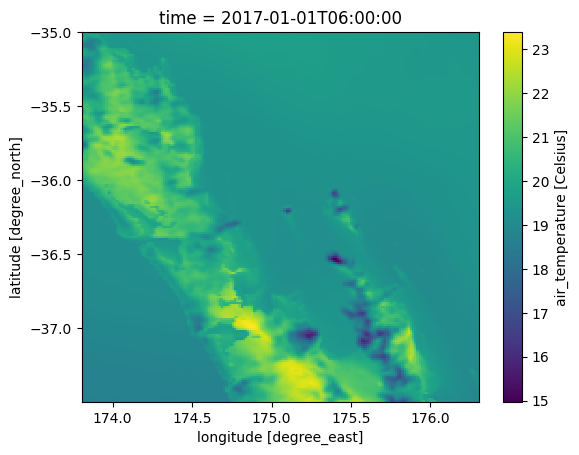

In [14]:
# plot some NZRA data
nzra_ds.isel(time=1)[target_var].plot()

#### Process the IFS dataset

In [15]:
# crop to NZRA bounds
ifs_ds = ifs_ds.sel(
    {
        LONGITUDE: slice(crop_left, crop_right),
        LATITUDE: slice(crop_bottom, crop_top),
    }
)

In [16]:
ifs_ds[SUN_CULMINATION] = get_sun_culmination(ifs_ds.coords)
ifs_ds[SUN_ANGLE] = get_sun_position(ifs_ds.coords)

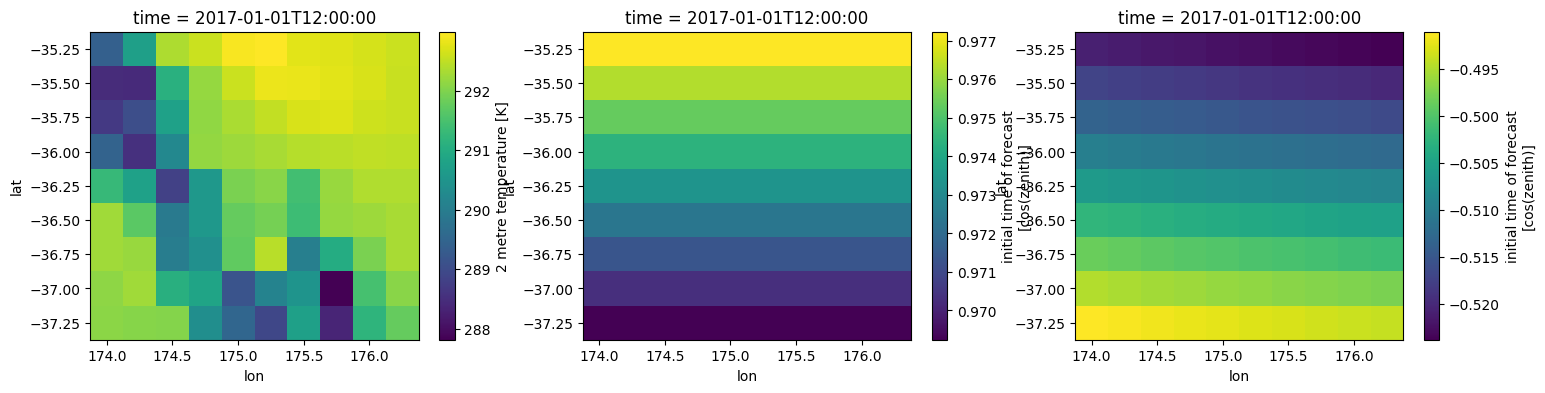

In [17]:
# plot some NZRA and sun angle data for testing
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

ifs_ds.isel(time=2)[target_var].plot(ax=ax[0])
ifs_ds.isel(time=2)[SUN_CULMINATION].plot(ax=ax[1])
ifs_ds.isel(time=2)[SUN_ANGLE].plot(ax=ax[2])

In [84]:
ifs_ds = ifs_ds[[TEMPERATURE, SUN_CULMINATION, SUN_ANGLE]]

#### Add the Auxiliary dataset

In [41]:
logger.info("Processing Auxiliary")

2025-12-12 13:32:46 - INFO - __main__ - Processing Auxiliary


In [ ]:
# build the auxiliary set
ds_aux = topography_processor.compute_tpi(topography_ds, window_sizes=[0.1])

ds_aux[LAND_SEA_MASK] = ds_aux[ELEVATION].where(ds_aux[ELEVATION].isnull(), 1, 0).fillna(0)

In [43]:
AUXILIARY_COARSEN_FACTOR = 10
ds_aux_coarse  = ds_aux.coarsen(
    lat=AUXILIARY_COARSEN_FACTOR, 
    lon=AUXILIARY_COARSEN_FACTOR, 
    boundary='trim').mean()

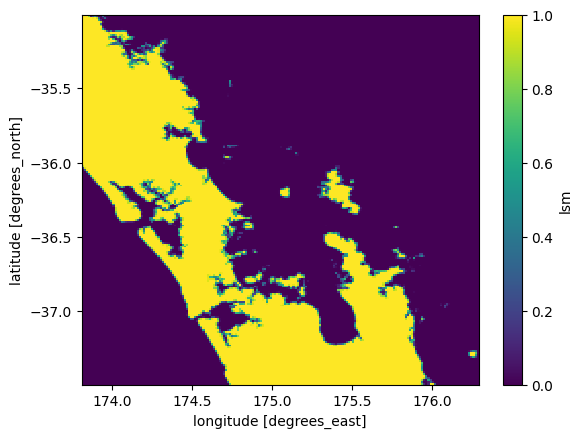

In [53]:
ds_aux_coarse[LAND_SEA_MASK].plot()

In [ ]:
# FYI training loop fails if you don't do this
ds_aux = ds_aux.fillna(0)
ds_aux_coarse = ds_aux_coarse.fillna(0)

In [55]:
ds_aux = ds_aux.sel(lat=slice(crop_bottom, crop_top), lon=slice(crop_left, crop_right))
ds_aux_coarse = ds_aux_coarse.sel(lat=slice(crop_bottom, crop_top), lon=slice(crop_left, crop_right))

#### Retrieve the Himawari 8 Dataset

In [57]:
logger.info("Processing Himawari 8")

2025-12-12 13:51:33 - INFO - __main__ - Processing Himawari 8


In [58]:
valid_timesteps_b3 = h8_processor.get_valid_timesteps_vectorised(h8_ds, BAND_3)

In [59]:
h8_ds = h8_ds.sel(time=valid_timesteps_b3)[BAND_3]

# there are a small number of duplicate timestamps in H8 data, we need to remove these
h8_ds = h8_ds.drop_duplicates(dim='time', keep='first')

In [60]:
h8_ds = h8_ds.resample(time="6h").pad(tolerance="6h") # bring forward values within 1 hour

In [61]:
h8_ds = h8_ds.reindex(time=nzra_ds.time)

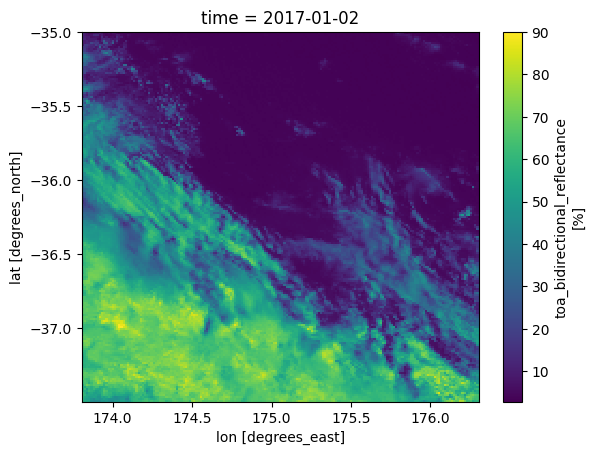

In [67]:
h8_ds.sel(time="2017-01-02 00:00:00").plot()

For these initial experiments I am going to omit the H8 satellite data

#### Retrieve the station information

In [68]:
logger.info("Processing Stations")

2025-12-12 14:01:10 - INFO - __main__ - Processing Stations


In [72]:
stations_df = station_processor.load_df([target_var], csv_file='esnz-observations_temp_20170101-20171231.csv', year_start=2017, year_end=2017)

stations_df = stations_df[[target_var, LATITUDE, LONGITUDE, TIME]]

stations_reset = stations_df.reset_index()
stations_resample = stations_reset.groupby([LATITUDE, LONGITUDE]).resample("6h", on=TIME).mean()[[target_var]]
stations_resample = stations_resample.reset_index().set_index([TIME, LATITUDE, LONGITUDE]).sort_index()
stations_resample = stations_resample[(stations_resample.index.get_level_values(LATITUDE) > crop_bottom) & (stations_resample.index.get_level_values(LATITUDE) < crop_top) &
                                      (stations_resample.index.get_level_values(LONGITUDE) > crop_left) & (stations_resample.index.get_level_values(LONGITUDE) < crop_right)]

/tmp/ipykernel_484948/2798113918.py:6: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stations_resample = stations_reset.groupby([LATITUDE, LONGITUDE]).resample("6h", on=TIME).mean()[[target_var]]


In [73]:
stations_resample = stations_resample.dropna()

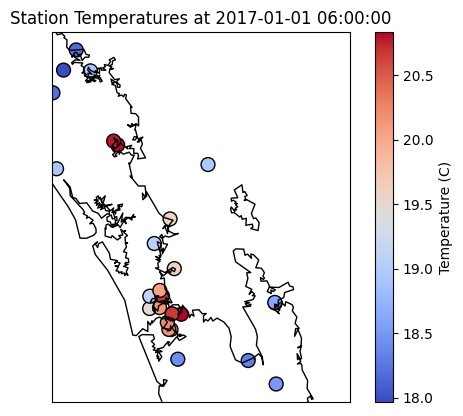

In [74]:
# visualise the stations

time_step = "2017-01-01 06:00:00"
m = Basemap(projection='merc', llcrnrlat=crop_bottom, urcrnrlat=crop_top, llcrnrlon=crop_left, urcrnrlon=crop_right, resolution='i')
m.drawcoastlines()
m.drawcountries()
x, y = m(stations_resample.reset_index().loc[stations_resample.reset_index()['time'] == time_step]['lon'].values,
           stations_resample.reset_index().loc[stations_resample.reset_index()['time'] == time_step]['lat'].values)
sc = m.scatter(x, y,
               c=stations_resample.reset_index().loc[stations_resample.reset_index()['time'] == time_step]['temperature'].values,
               cmap='coolwarm', marker='o', edgecolor='k', s=100)
plt.colorbar(sc, label='Temperature (C)')
plt.title(f'Station Temperatures at {time_step}')
plt.show()

#### Build the data processor

In [75]:
logger.info("Building the Data Processor")

2025-12-12 14:02:27 - INFO - __main__ - Building the Data Processor


In [85]:
data_processor = DataProcessor(
    x1_name=LATITUDE, 
    x1_map=(nzra_ds[LATITUDE].min(), nzra_ds[LATITUDE].max()), 
    x2_name=LONGITUDE, 
    x2_map=(nzra_ds[LONGITUDE].min(), nzra_ds[LONGITUDE].max()))

nzra_processed, ifs_processed, station_processed = data_processor([nzra_ds, ifs_ds, stations_resample])
ds_aux_processed, ds_aux_coarse_processed = data_processor([ds_aux, ds_aux_coarse], method='min_max')

/home/crowelenn/niwa/convcnp-assim-nz/venv/src/deepsensor/deepsensor/data/processor.py:129: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"x1_map={x1_map} and x2_map={x2_map} have different ranges ({float(np.diff(x1_map))} "
/home/crowelenn/niwa/convcnp-assim-nz/venv/src/deepsensor/deepsensor/data/processor.py:130: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"and {float(np.diff(x2_map))}, respectively). "
/home/crowelenn/niwa/convcnp-assim-nz/venv/src/deepsensor/deepsensor/data/processor.py:128: UserWarning: x1_map=(-37.4885, -35.00450000000001) and x2_map=(173.8125, 176.2965) have different ranges (2.4839999999999947 and 2.4840000000

In [ ]:
x1x2_ds = construct_x1x2_ds(ds_aux_coarse_processed)
ds_aux_coarse_processed['x1_arr'] = x1x2_ds['x1_arr']
ds_aux_coarse_processed['x2_arr'] = x1x2_ds['x2_arr']

task_loader = TaskLoader(
        context = [station_processed, ifs_processed, ds_aux_coarse_processed], 
        target = nzra_processed)

# default: internal_density inferred from TaskLoader: 475
model = ConvNP(data_processor, task_loader, unet_channels=(64,)*5, likelihood="gnp", internal_density=237)

dim_yc inferred from TaskLoader: (1, 3, 5)
dim_yt inferred from TaskLoader: 1
dim_aux_t inferred from TaskLoader: 0
internal_density inferred from TaskLoader: 475
encoder_scales inferred from TaskLoader: [0.0010526315789473684, 0.05032206326723099, 0.002576487371698022]
decoder_scale inferred from TaskLoader: 0.002105263157894737


In [31]:
season_slices = {
    "DJF_2017": ("2017-02-15T00", "2017-02-28T23"),  # last 2 weeks of DJF 2017
    "MAM_2017": ("2017-05-17T00", "2017-05-31T23"),
    "JJA_2017": ("2017-08-18T00", "2017-08-31T23"),
    "SON_2017": ("2017-11-17T00", "2017-11-30T23"),
}

# select each slice and store in a list
season_dfs = [
    nzra_ds.sel(time=slice(start, end))
    for start, end in season_slices.values()
]

In [32]:
validation_times = np.concatenate([season_dfs[i].time.values for i in range(len(season_dfs))])
train_times = np.setdiff1d(nzra_ds.time.values, validation_times)

In [33]:
train_tasks = []
for time in train_times:
    task = task_loader(time, context_sampling=["split", "all", "all", "all"], target_sampling=["split"], split_frac=0.5)
    train_tasks.append(task)

val_tasks = []
for time in validation_times:
    task = task_loader(time, context_sampling=["split", "all", "all", "all"], target_sampling=["split"], split_frac=0.5)
    val_tasks.append(task)

In [34]:
logger.info("Starting Nulls Check")

2025-12-11 13:58:47 - INFO - __main__ - Starting Nulls Check


In [35]:
nulls_nzra = []
nulls_h8 = []
nulls_sample_size = 500

for time in np.random.choice(train_times, size=nulls_sample_size):
    nulls_nzra.append(np.all(nzra_ds.sel(time=time)[target_var].isnull().values))
    nulls_h8.append(np.all(h8_ds.sel(time=time).isnull().values))

In [36]:
print(f"Nulls % in NZRA, based off a sample of {nulls_sample_size}: {np.sum(nulls_nzra)/len(nulls_nzra)}")
print(f"Nulls % in Himawari 8, based off a sample of {nulls_sample_size}: {np.sum(nulls_h8)/len(nulls_h8)}")

Nulls % in NZRA, based off a sample of 500: 0.134
Nulls % in Himawari 8, based off a sample of 500: 0.8


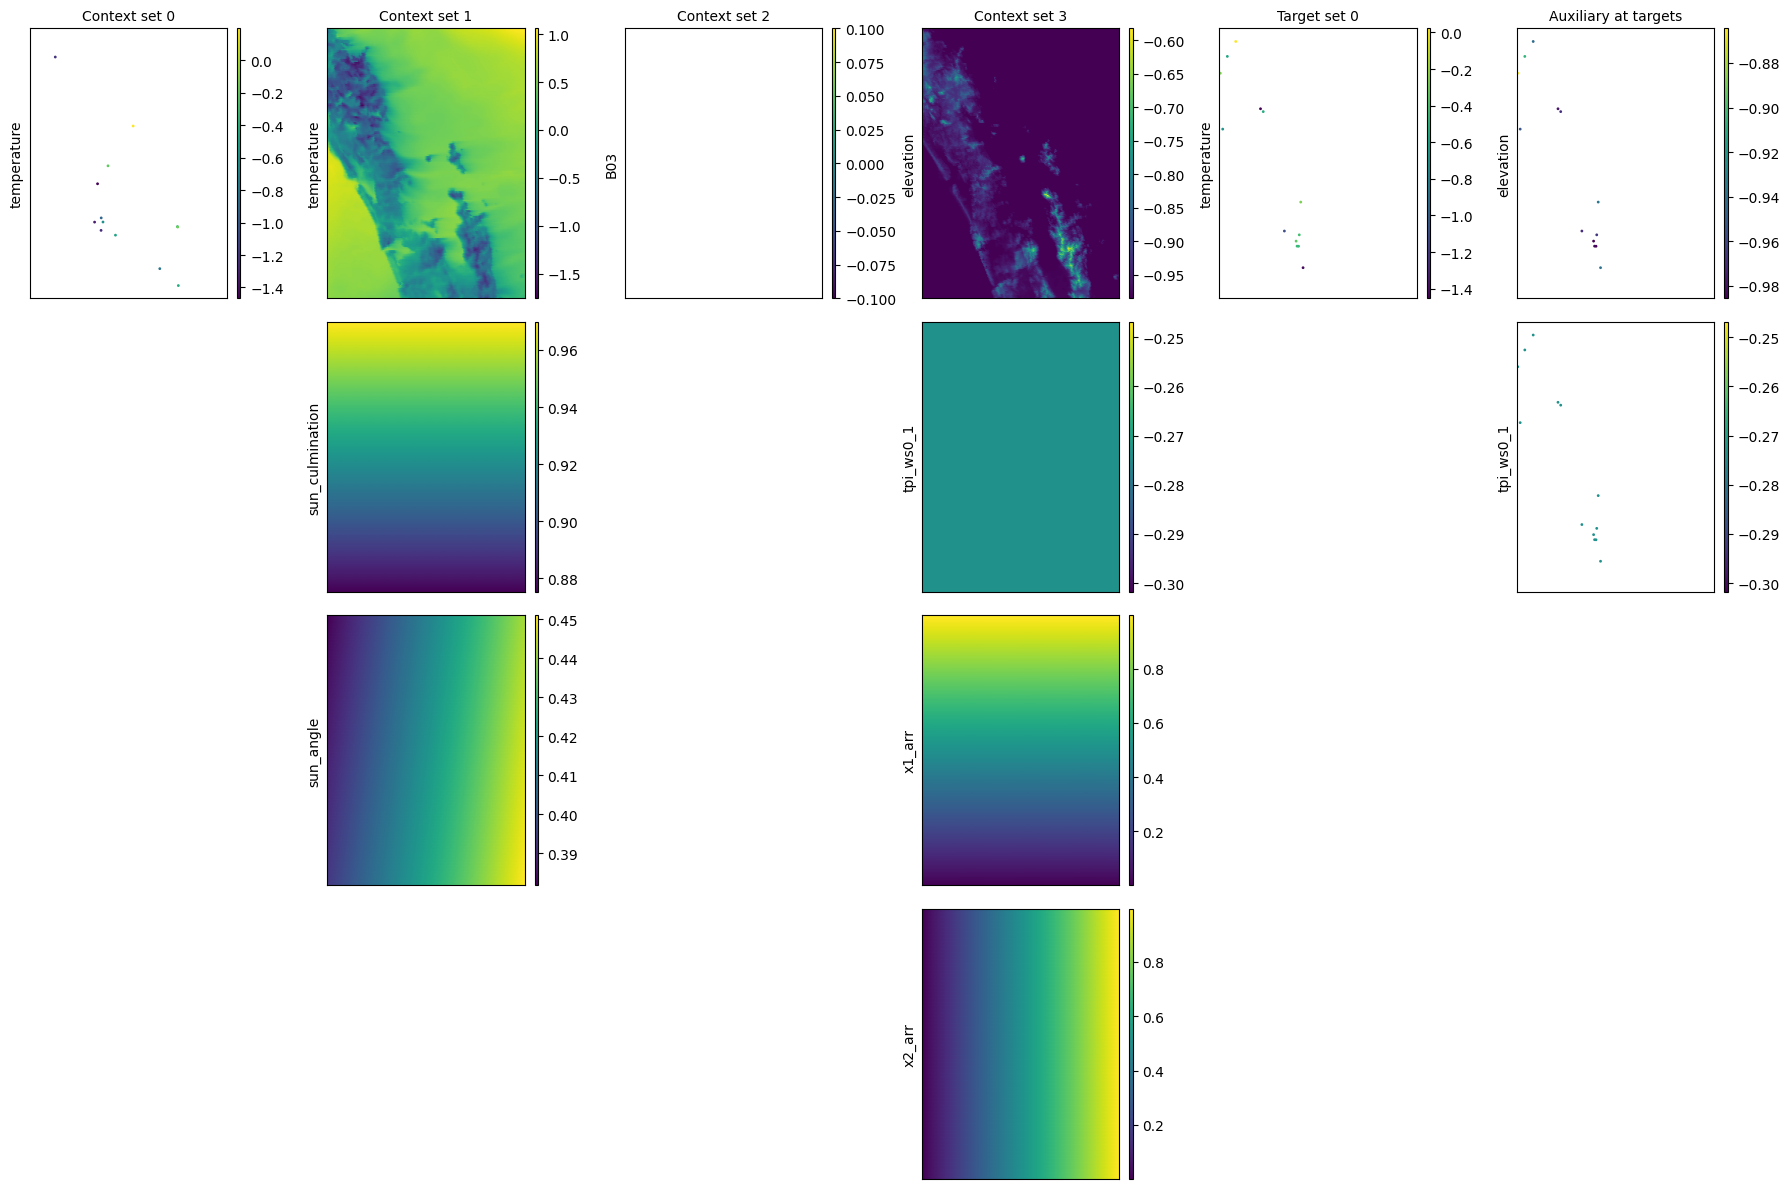

In [37]:
deepsensor.plot.task(train_tasks[1000], task_loader)
plt.show()

In [38]:
logger.info("Creating Batches")

2025-12-11 14:00:48 - INFO - __main__ - Creating Batches


In [39]:
BATCH_SIZE = 16

In [40]:
def batch_data_by_num_stations_test(tasks, batch_size=None):
        # if batch_size == None, return a dict in which each key value pair is a 
        # list of *all of the tasks* with the same number of stations
        batched_tasks = {}
        for task in tasks:
            num_stations = task['X_t'][0].shape[1]
            if num_stations == 0:
                pass
            elif f'{num_stations}' not in batched_tasks.keys():
                batched_tasks[f'{num_stations}'] = [task]
            else:
                batched_tasks[f'{num_stations}'].append(task)

        # if batch_size is not None, return a dict in which each key value pair is a
        # list of tasks with the same number of stations, but with batch_size number of tasks
        # e.g. if batch_size = 4 but there are 10 tasks with 100 stations, then there will be 100 keys:
        # '100_0' with 4 tasks, '100_1' with 4 tasks, '100_2' with 2 tasks
                
        # reason for doing it like this: if we set a large batch_size, e.g. 16, and there are 
        # only 10 tasks with 100 stations, then the deepsensor train_epoch function will 
        # ignore these tasks 
        if batch_size is not None:
            batched_tasks_copy = batched_tasks.copy()
            batched_tasks = {}
            for num_stations in batched_tasks_copy.keys():
                number_tasks_in_batch = len(batched_tasks_copy[f'{num_stations}'])
                for idx, i in enumerate(range(0, number_tasks_in_batch, batch_size)):
                    batched_tasks[f'{num_stations}_{idx}'] = batched_tasks_copy[f'{num_stations}'][i:i+batch_size]

        return batched_tasks

In [41]:
train_tasks_batched = batch_data_by_num_stations(train_tasks, batch_size=BATCH_SIZE)
validation_tasks_batched = batch_data_by_num_stations(val_tasks, batch_size=BATCH_SIZE)

# group the tasks into batches
train_tasks_epoch = [ concat_tasks(train_tasks_batched[f"{train_task_id}"]) for train_task_id in train_tasks_batched.keys()]
val_tasks_epoch = [ concat_tasks(validation_tasks_batched[f"{val_task_id}"]) for val_task_id in validation_tasks_batched.keys()]

/home/crowelenn/niwa/convcnp-assim-nz/venv/lib/python3.12/site-packages/lab/types.py:204: DeprecationWarning: numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numerictypes.
  for name in np.core.numerictypes.__all__ + ["bool"]:


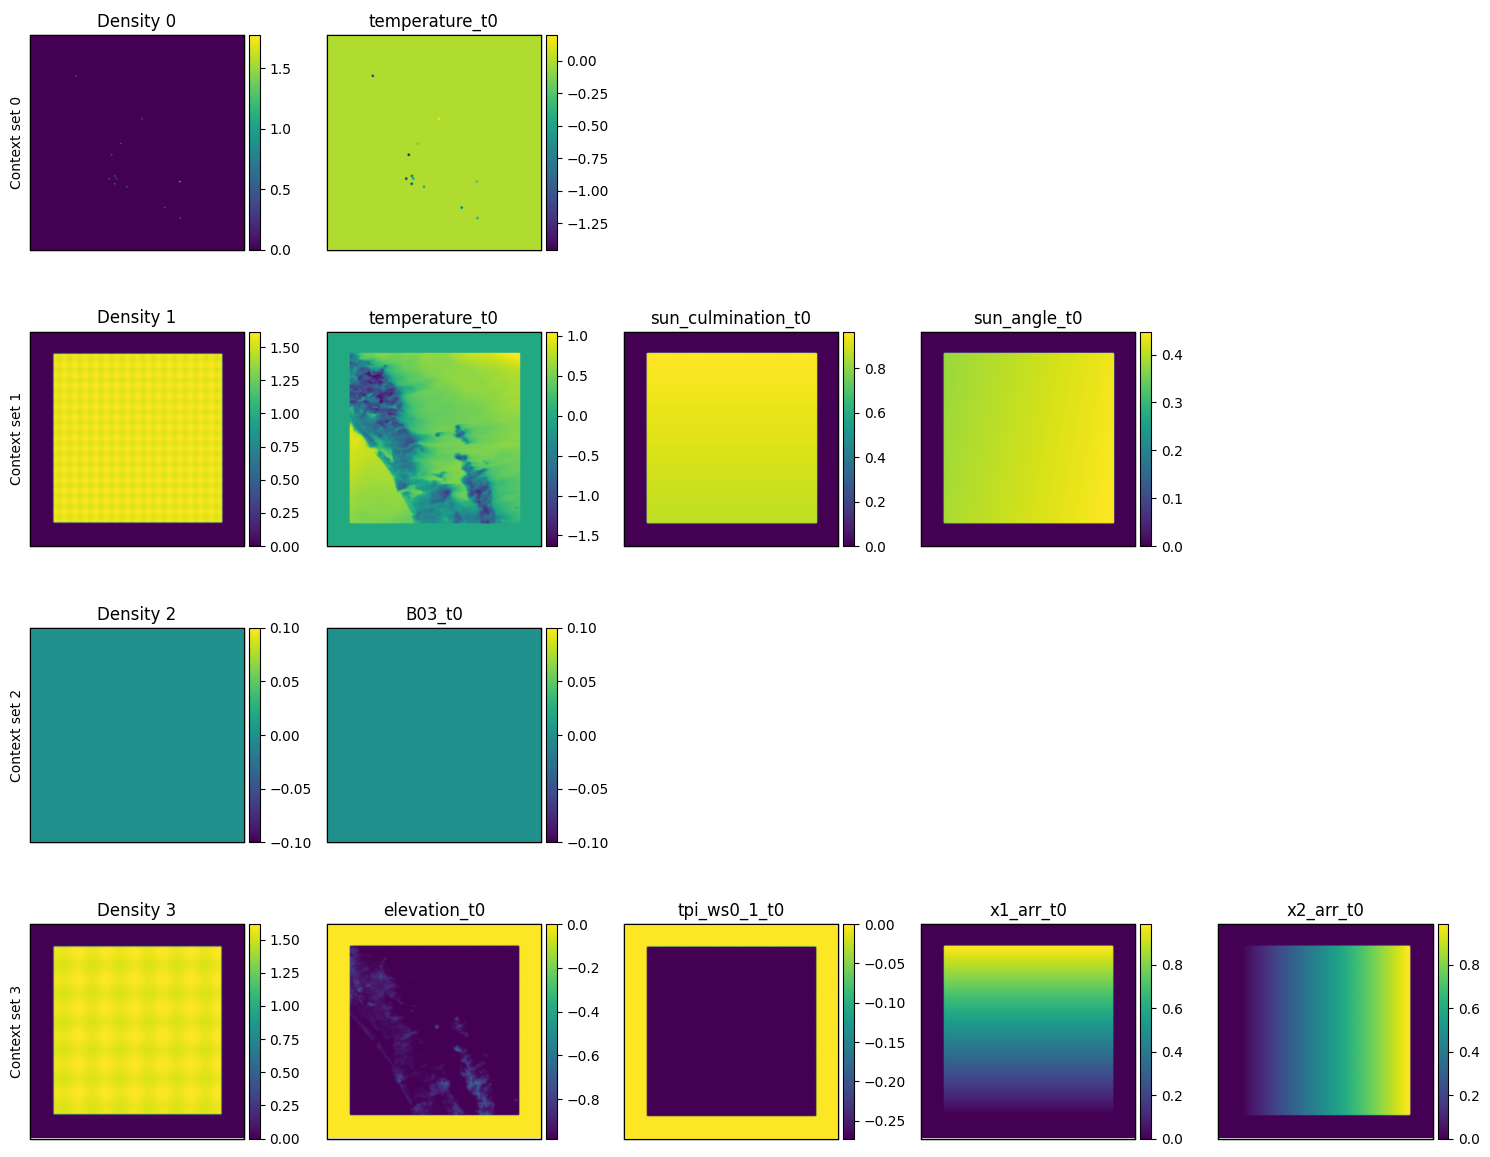

In [42]:
fig = deepsensor.plot.context_encoding(model, train_tasks[1000], task_loader)

In [43]:
logger.info("Starting Model Training")

2025-12-11 14:02:42 - INFO - __main__ - Starting Model Training


In [44]:
train_tasks_epoch[-1-3]

time: ['Timestamp/2017-10-28 00:00:00', 'Timestamp/2017-10-28 01:00:00', 'Timestamp/2017-10-28 02:00:00', 'Timestamp/2017-10-30 09:00:00', 'Timestamp/2017-11-01 13:00:00', 'Timestamp/2017-11-01 22:00:00', 'Timestamp/2017-11-01 23:00:00', 'Timestamp/2017-11-02 12:00:00', 'Timestamp/2017-11-04 03:00:00', 'Timestamp/2017-11-05 00:00:00', 'Timestamp/2017-11-05 01:00:00', 'Timestamp/2017-11-05 02:00:00', 'Timestamp/2017-11-05 06:00:00', 'Timestamp/2017-11-05 08:00:00', 'Timestamp/2017-11-07 18:00:00', 'Timestamp/2017-11-08 15:00:00']
ops: ['str/batch_dim', 'str/float32', 'str/numpy_mask', 'str/nps_mask']
X_c: ['ndarray/float32/(16, 2, 10)', ('ndarray/float32/(16, 1, 185)', 'ndarray/float32/(16, 1, 185)'), ('ndarray/float32/(16, 1, 185)', 'ndarray/float32/(16, 1, 185)'), ('ndarray/float32/(16, 1, 194)', 'ndarray/float32/(16, 1, 194)')]
Y_c: ['Masked/(y=float32/(16, 1, 10))/(mask=bool/(16, 1, 10))', 'Masked/(y=float32/(16, 3, 185, 185))/(mask=bool/(16, 1, 185, 185))', 'Masked/(y=float32/(16, 

In [45]:
mask = np.array([train_tasks_epoch[i]['X_t'][0].shape[1] == 0 for i in range(len(train_tasks_epoch))])

In [46]:
for i in range(len(train_tasks)):
    if train_tasks[i]['X_t'][0].shape[1] == 0:
        print(i)

7366
7367
7368
7369
7370
7371
7372
7373
7374
7375
7376
7377
7378
7379
7380
7381
7382
7383
7384
7385
7386
7387
7388


In [47]:
stations_df.sort_values('time')

,temperature,lat,lon,time
284601,21.65,-41.30081,173.21608,2017-01-01
264458,17.25,-41.27058,172.15568,2017-01-01
264459,10.35,-42.46022,171.19157,2017-01-01
264460,18.05,-42.68168,171.45628,2017-01-01
264461,17.75,-43.36548,170.13428,2017-01-01
...,...,...,...,...
1944600,18.85,-43.67767,171.58840,2017-12-31
1944605,20.75,-43.07026,172.65344,2017-12-31
1944617,13.10,-44.38112,168.92633,2017-12-31
1188695,-2.85,NaN,NaN,2017-12-31


In [48]:
stations_df[stations_df['time'] == '2017-12-31']

,temperature,lat,lon,time
1188669,-2.20,NaN,NaN,2017-12-31
1188672,0.70,NaN,NaN,2017-12-31
1188676,1.80,NaN,NaN,2017-12-31
1188682,3.50,NaN,NaN,2017-12-31
1188685,2.45,NaN,NaN,2017-12-31
...,...,...,...,...
2122897,27.70,-21.20109,-159.81329,2017-12-31
2129156,2.00,NaN,NaN,2017-12-31
2135893,1.30,NaN,NaN,2017-12-31
2135894,-0.20,NaN,NaN,2017-12-31


In [49]:
train_tasks_epoch[10]['X_t'][0].shape

(16, 2, 13)

In [50]:
len(mask)

464

In [51]:
train_tasks_filter = [train_tasks_epoch for train_tasks_epoch, mask in zip(train_tasks_epoch, mask) if mask]

In [52]:
from deepsensor.train import Trainer

In [53]:
trainer = Trainer(model, lr=5e-5)

In [54]:
def train_epoch_test(
    model,
    tasks,
    lr,
    batch_size=None,
    opt=None,
    progress_bar=False,
    tqdm_notebook=False,
):
    """Train model for one epoch.

    Args:
        model (:class:`~.model.convnp.ConvNP`):
            Model to train.
        tasks (List[:class:`~.data.task.Task`]):
            List of tasks to train on.
        lr (float, optional):
            Learning rate, by default 5e-5.
        batch_size (int, optional):
            Batch size. Defaults to None. If None, no batching is performed.
        opt (Optimizer, optional):
            TF or Torch optimizer. Defaults to None. If None,
            :class:`tensorflow:tensorflow.keras.optimizer.Adam` is used.
        progress_bar (bool, optional):
            Whether to display a progress bar. Defaults to False.
        tqdm_notebook (bool, optional):
            Whether to use a notebook progress bar. Defaults to False.

    Returns:
        List[float]: List of losses for each task/batch.
    """
    if deepsensor.backend.str == "tf":
        import tensorflow as tf

        if opt is None:
            opt = tf.keras.optimizers.Adam(lr)

        def train_step(tasks):
            if not isinstance(tasks, list):
                tasks = [tasks]
            with tf.GradientTape() as tape:
                task_losses = []
                for task in tasks:
                    task_losses.append(model.loss_fn(task, normalise=True))
                mean_batch_loss = B.mean(B.stack(*task_losses))
            grads = tape.gradient(mean_batch_loss, model.model.trainable_weights)
            opt.apply_gradients(zip(grads, model.model.trainable_weights))
            return mean_batch_loss

    elif deepsensor.backend.str == "torch":
        import torch.optim as optim

        if opt is None:
            opt = optim.Adam(model.model.parameters(), lr=lr)

        def train_step(tasks):
            if not isinstance(tasks, list):
                tasks = [tasks]
            opt.zero_grad()
            task_losses = []
            for task in tasks:
                task_losses.append(model.loss_fn(task, normalise=True))
            mean_batch_loss = B.mean(B.stack(*task_losses))
            mean_batch_loss.backward()
            opt.step()

            loss = mean_batch_loss.detach().cpu().numpy()

            if mean_batch_loss == None:
                print("NaN detected")

            return mean_batch_loss.detach().cpu().numpy()

    else:
        raise NotImplementedError(f"Backend {deepsensor.backend.str} not implemented")

    tasks = np.random.permutation(tasks)

    if batch_size is not None:
        n_batches = len(tasks) // batch_size  # Note that this will drop the remainder
    else:
        n_batches = len(tasks)

    if tqdm_notebook:
        from tqdm.notebook import tqdm
    else:
        from tqdm import tqdm

    batch_losses = []
    for batch_i in tqdm(range(n_batches), disable=not progress_bar):
        if batch_size is not None:
            task = concat_tasks(
                tasks[batch_i * batch_size : (batch_i + 1) * batch_size]
            )
        else:
            task = tasks[batch_i]
        batch_loss = train_step(task)
        if np.isnan(batch_loss):
            print("NAN")
        batch_losses.append(batch_loss)

    return batch_losses

In [56]:
# training loop. Train baseline model for 50 epochs.
n_epochs = 2
lr=5e-5 * 2

opt = optim.Adam(model.model.parameters(), lr=lr)

for epoch in range(n_epochs):
    #batch_losses = trainer(train_tasks_epoch)
    batch_losses = train_epoch(model, train_tasks_epoch, lr)
    
    train_loss = np.mean(batch_losses)
    # write the train loss to tensorboard
    tb_writer.add_scalar(TB_TRAIN_LOSS, train_loss, epoch+1)
    tb_writer.add_scalar('GPU Memory Usage (MiB)', torch.cuda.max_memory_reserved()/1024**2, epoch+1)
    tb_writer.flush()

    # you could add early stopping or model checkpointing here

    if (epoch + 1) % 1 == 0:
        with torch.no_grad():
            val_loss = compute_val_loss(model, val_tasks_epoch)
            tb_writer.add_scalar(TB_VAL_LOSS, val_loss, epoch+1)
            tb_writer.flush()

        logger.info(f"Epoch {epoch+1} train_loss: {train_loss:.2f}, val_loss: {val_loss:.2f}")
    

2025-12-11 14:06:34 - INFO - __main__ - Epoch 1 train_loss: 0.73, val_loss: 0.85
2025-12-11 14:08:23 - INFO - __main__ - Epoch 2 train_loss: 0.70, val_loss: 0.74
